# Research Notebook
## Haotian Xiao
## Date: 2026 Feb 10 - 2026 Mar 20

# 1: Experience
## Describe at least one research activity you worked on this week. 

This week, I focused on the MCMC stage of the SIDM halo project. After finalizing the temperature-profile selection work, I used MCMC to sample the posterior distribution of the halo and gas parameters in our forward model. The main parameters in the run were M200 (virial mass,sets the overall mass scale of the dark matter halo), c (concentration of the halo),Upsilon (stellar mass-to-light ratio), rho0 (gas density normalization),rm (matching radius, describing how far the inner modified halo solution extends before matching onto the outer halo) . My work this week focused especially on understanding how to interpret the main MCMC diagnostic plots, including the trace plot and the corner plot, and on assessing whether the chains were mixing well enough to support later physical interpretation. I also started connecting the posterior samples to the next physics step, which is to rebuild the Jeans profile for many samples and compute σ/m using function profile.cross_section() in Jeans package.

## Motivation:

The motivation for this work was that a single best-fit halo model is not enough for this project. The parameters in the model are correlated, so different parameter combinations can produce similarly acceptable projected gas profiles. Because of that, I needed a posterior-based method rather than a single optimization result. MCMC allows me to quantify parameter uncertainties, identify degeneracies, and eventually propagate those uncertainties into a posterior or upper limit for σ/m. This stage is therefore the bridge between the earlier temperature-profile work and the final SIDM interpretation.

# 2: What? (What happened?)
## Describe what happened during your activities for the week.

During this week, I ran MCMC on all the Humphrey paper and Gastaldello paper systems（see more details in research journal 1&2) and then examined the behavior of the MCMC chains in detail. The first diagnostic I used was the trace plot. In the trace plot, each colored curve corresponds to one walker, and each panel corresponds to one parameter. The main question I asked was whether, after burn-in, the walkers were fluctuating around the same posterior region or whether they were still drifting systematically over the run. I found that some parameters settled into relatively tight bands, while others remained much broader. This did not automatically indicate a failure, because some parameters are intrinsically more weakly constrained than others. 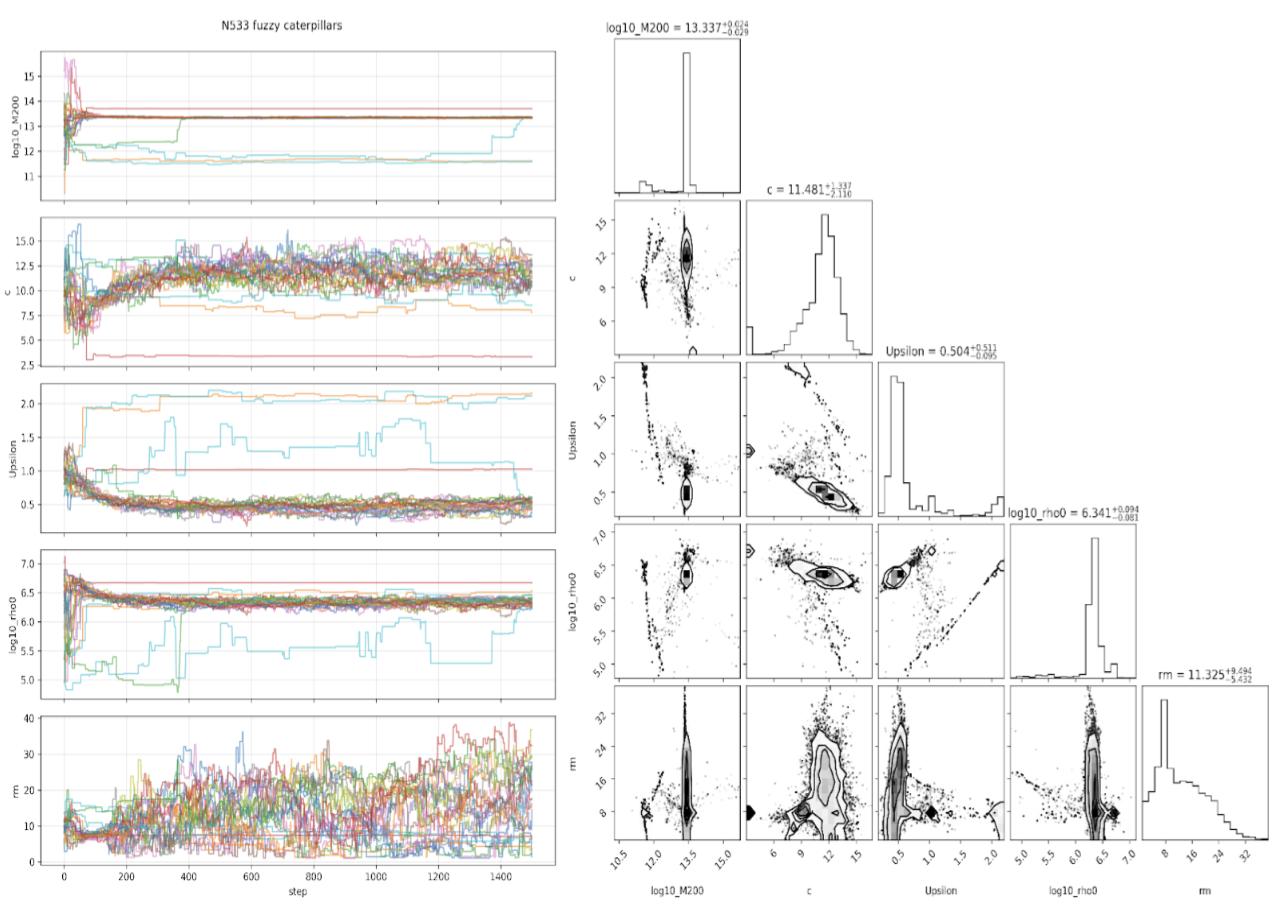

I then used the corner plot to study the posterior structure itself. The diagonal panels show the one-dimensional posterior distributions, while the off-diagonal panels show correlations and degeneracies between parameters. This was particularly important in our project because parameters can trade off against one another. One useful observation was that for a positive scale parameter such as rm, a log-parameterization often makes the posterior easier to interpret than a linear parameterization.(see comparison figures below)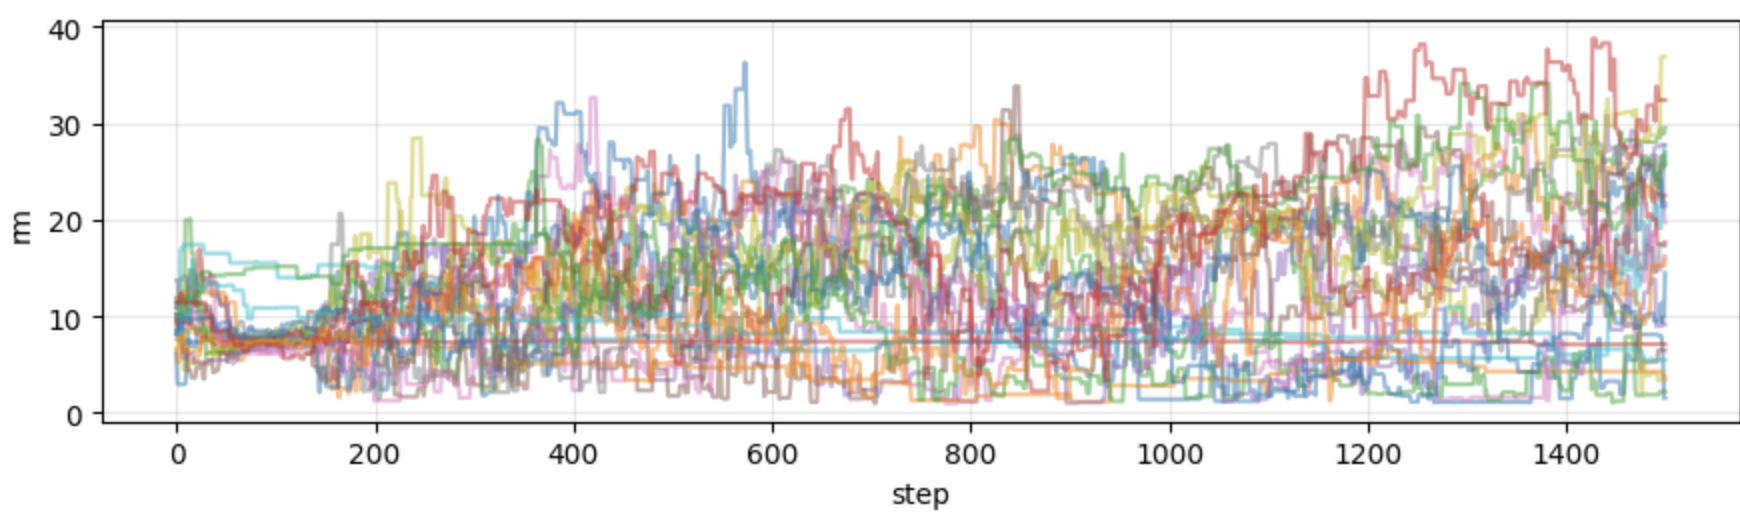 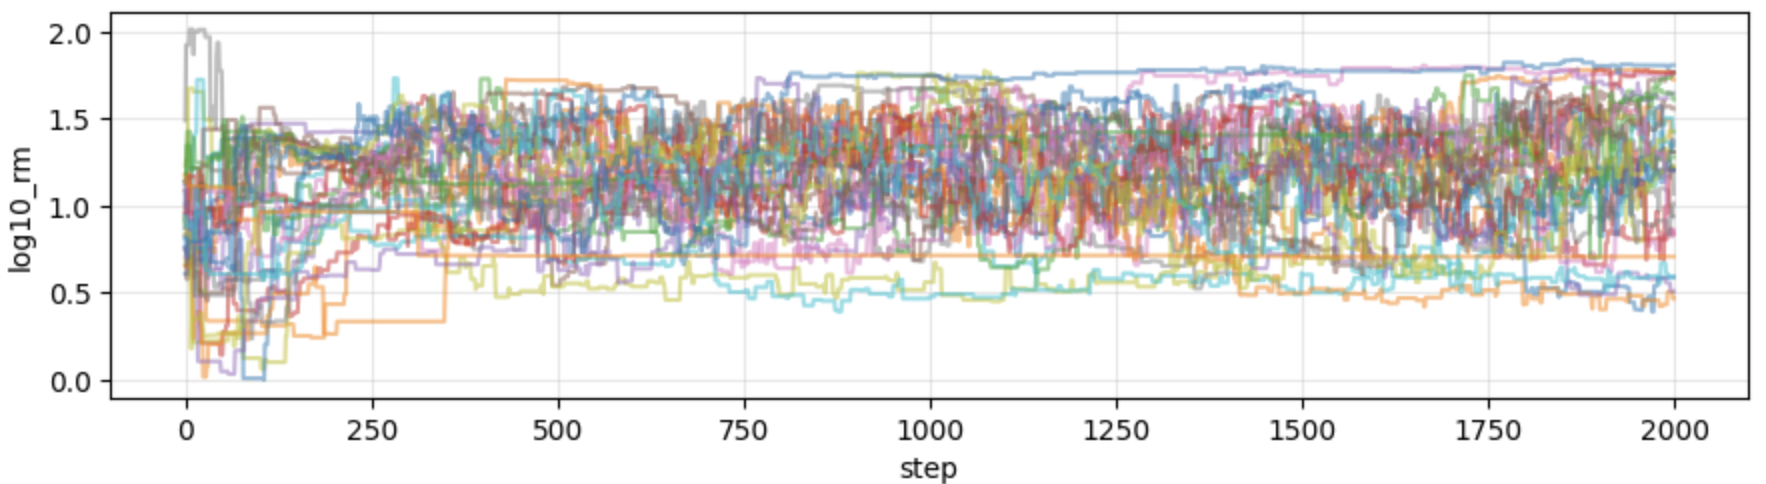

I also compared visual diagnostics with quantitative diagnostics. In addition to looking at the trace and corner plots, I used reduced χ2（compared the MCMC parameters resulting best-fit curve with the original dataset）and autocorrelation time tau to assess whether a run was acceptable(a reasonable chain should usually be several tens of tau long rather than only a small multiple of tau). The trace plot tells me whether the chain is dynamically behaving well, while the corner plot tells me what the posterior actually looks like statistically. I therefore treated these two plots as complementary tools rather than relying on only one of them.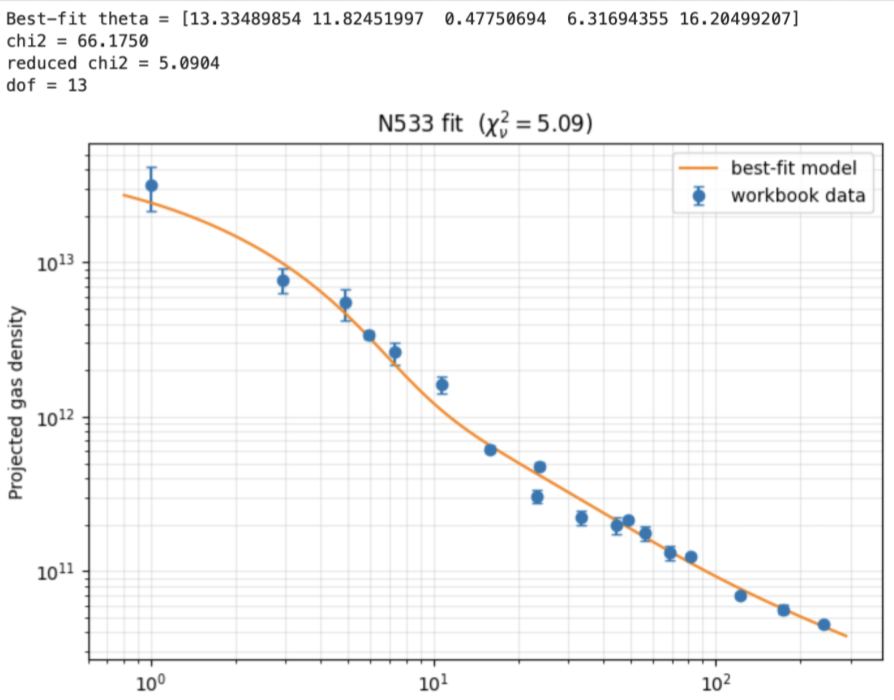

# 3: So what? (What does it mean?)
## Describe your results

The main result of this week’s work is that the MCMC output is already physically informative even before converting it to sigma/m. The posterior distributions show which parameters are well constrained and which remain broad, and the off-diagonal structure in the corner plot makes the main degeneracies visible. In particular, the runs show that rm is one of the more difficult parameters to constrain, which is consistent with its role as a structural transition scale rather than a simple amplitude parameter.

Another important result is methodological: a reasonable-looking best-fit curve is not sufficient by itself. A chain may produce an acceptable fit visually, but still be too short or too correlated to support strong conclusions. That is why the autocorrelation time and reduced chi2 are important in addition to the trace and corner plots. In other words, a “good” MCMC result in this project means not only a decent fit, but also a chain that has mixed well enough and a posterior that can be interpreted consistently.

For the Gastaldello and Humphrey systems(23 in total), the reduced chi2 values from our runs are generally below about 8, and the best-fit projected gas curves are broadly consistent with the best-fit behavior shown in the original papers. This suggests that both our adopted temperature profiles and the MCMC pipeline are producing physically reasonable results. Taken together, these results support the idea that the current temperature-profile selection and MCMC framework are a sensible basis for the next step of propagating the posterior into sigma/m.

# 4. Now what? (What's next?)
## Plan for the next week

My plan for the next stage is to move from interpreting the MCMC posterior to explicitly propagating it into σ/m. The intended workflow is to take many posterior samples from the chain, rebuild the corresponding Jeans profile for each sample, and then evaluate profile.cross_section() to obtain a posterior array of σ/m values. From that array, I plan to report either a confidence interval or an upper limit, depending on how well constrained the resulting distribution is.

In parallel, I also want to continue checking the robustness of the MCMC runs. In particular, I want to compare whether longer chains or different parameterizations improve the autocorrelation-time diagnostics and make the posterior for rm more stable(the current MCMC chain length is not long enough, need to be improved before resulting sigma/m)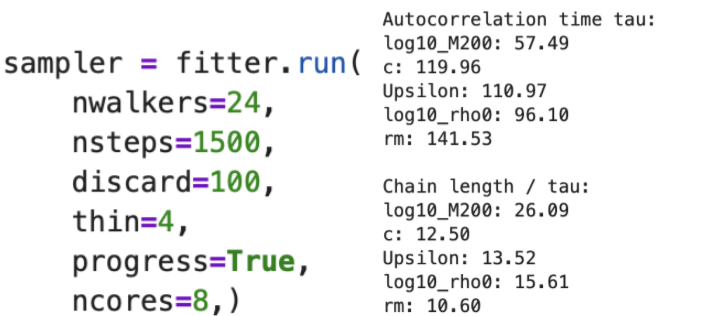. 
So the next step will focus both on improving confidence in the posterior itself and on translating that posterior into a physically meaningful SIDM constraint.

# 5. Bibliography

1.Foreman-Mackey, D., Hogg, D. W., Lang, D., & Goodman, J. (2013). emcee: The MCMC Hammer.
2.Burnham, K. P., & Anderson, D. R. Model Selection and Multimodel Inference.
3.Humphrey, P. J., et al. (2006). "A Chandra View of Dark Matter in Early-Type Galaxies." The Astrophysical Journal.
4.Gastaldello, F., et al. (2007). "Probing the Dark Matter and Gas Fraction in Relaxed Galaxy Groups with X-Ray Observations." The Astrophysical Journal.